In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [16]:
df=pd.read_csv("TSLA_5Y_1DAY_FROM_PERPLEXITY.csv",parse_dates=True,index_col='date')
df.head()

,close,open,high,low,volume
date,,,,,
2021-02-22 00:00:00-05:00,238.17,254.21,256.17,236.73,111809100.0
2021-02-23 00:00:00-05:00,232.95,220.71,237.87,206.33,199820700.0
2021-02-24 00:00:00-05:00,247.34,237.28,248.33,231.39,110301000.0
2021-02-25 00:00:00-05:00,227.41,242.05,245.74,223.53,117071700.0
2021-02-26 00:00:00-05:00,225.17,233.33,235.57,219.84,123267600.0


Since the volume column is of continuous data type we will use line graph to visualize it.\

sns.lineplot(data=df, x=df.index, y='High', label='High Price', color='blue'): Plots High prices over time using the datetime index on x-axis.

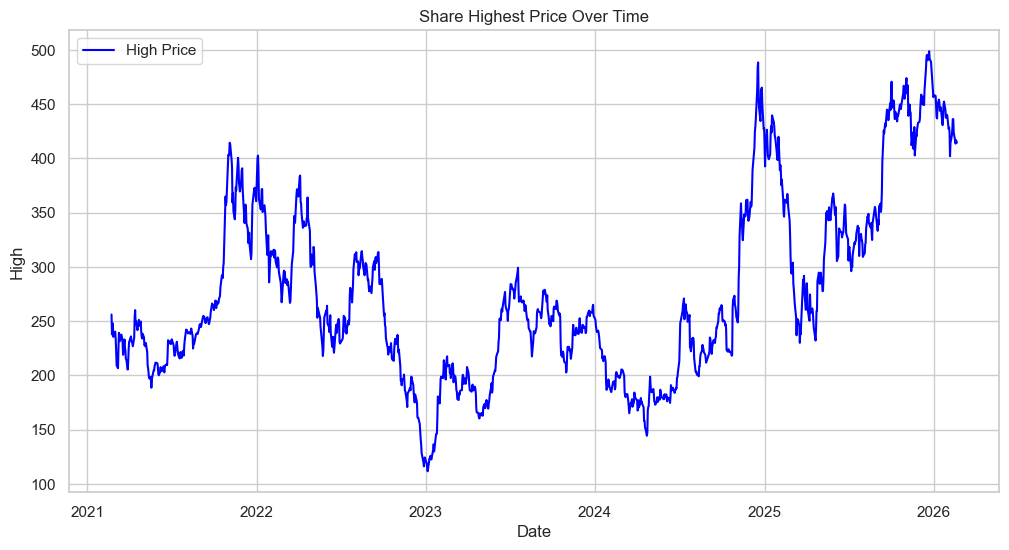

In [17]:
sns.set(style="whitegrid") 

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='high', label='High Price', color='blue')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Share Highest Price Over Time')

plt.show()

To better understand the trend of the data we will use the resampling method which provide a clearer view of trends and patterns when we are dealing with daily data.\

df_resampled = df.resample('M').mean(numeric_only=True): Resamples data to monthly frequency and calculates the mean of all numeric columns for each month.

In [18]:
df_resampled = df.resample('ME').mean(numeric_only=True) 

sns.set(style="whitegrid") 

plt.figure(figsize=(12, 6))  
sns.lineplot(data=df_resampled, x=df_resampled.index, y='High', label='Month Wise Average High Price', color='blue')

plt.xlabel('Date (Monthly)')
plt.ylabel('High')
plt.title('Monthly Resampling Highest Price Over Time')

plt.show()

ValueError: Invalid frequency: ME

We will detect Seasonality using the autocorrelation function (ACF) plot. Peaks at regular intervals in the ACF plot suggest the presence of seasonality.

'Date' is already the index or not present in the DataFrame.


<Figure size 1200x600 with 0 Axes>

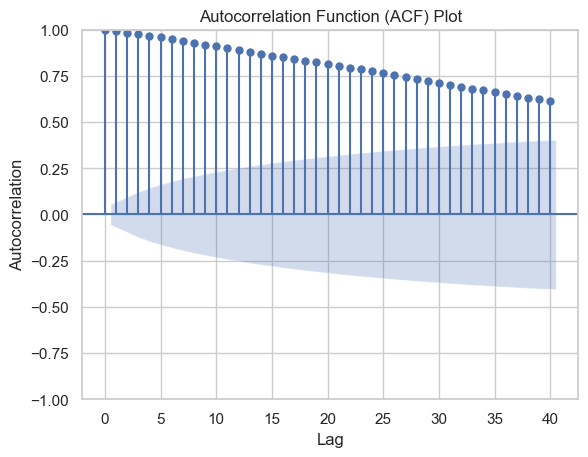

In [ ]:
if 'date' not in df.columns:
    print("'Date' is already the index or not present in the DataFrame.")
else:
    df.set_index('date', inplace=True)

plt.figure(figsize=(12, 6))
plot_acf(df['high'], lags=40)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF) Plot')
plt.show()

In [ ]:
#We will detect Seasonality using the autocorrelation function (ACF) plot. Peaks at regular intervals in the ACF plot suggest the presence of seasonality.
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['high'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -1.9401162820826978
p-value: 0.31343072454958676
Critical Values: {'1%': -3.435630320520318, '5%': -2.863871779019612, '10%': -2.56801146937726}


Based on the ADF Statistic we accept the null hypothesis and check that the data does not appear to be stationary according to the Augmented Dickey-Fuller test.\
This suggests that differencing or other transformations may be needed to achieve stationarity before applying certain time series models.\
Step 8: Differencing to Achieve Stationarity<br>
Differencing involves subtracting the previous observation from the current observation to remove trends or seasonality.

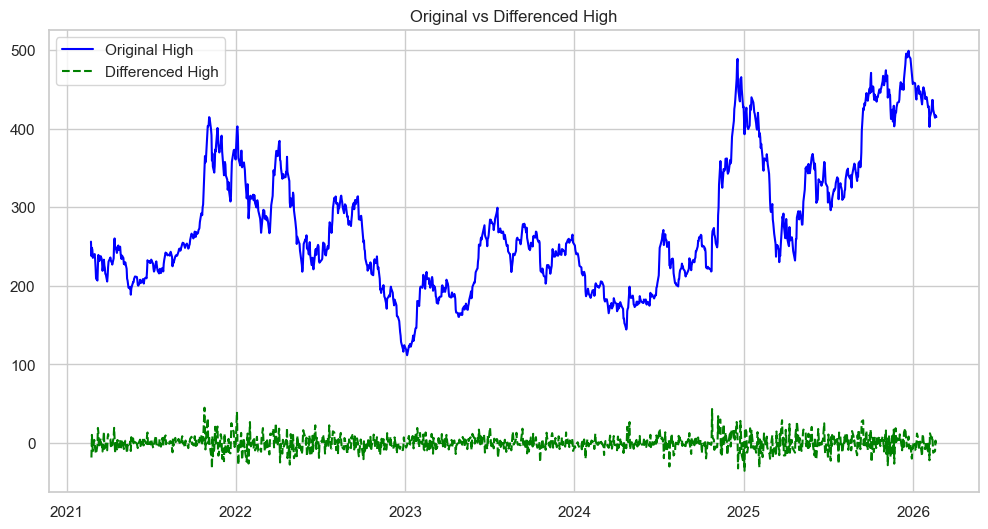

In [24]:
df['high_diff'] = df['high'].diff()

plt.figure(figsize=(12, 6))
plt.plot(df['high'], label='Original High', color='blue')
plt.plot(df['high_diff'], label='Differenced High', linestyle='--', color='green')
plt.legend()
plt.title('Original vs Differenced High')
plt.show()

Step 9: Smoothing Data with Moving Average\
df['High'].diff(): helps in calculating the difference between consecutive values in the High column. This differencing operation is used to transform a time series into a new series that represents the changes between consecutive observations.

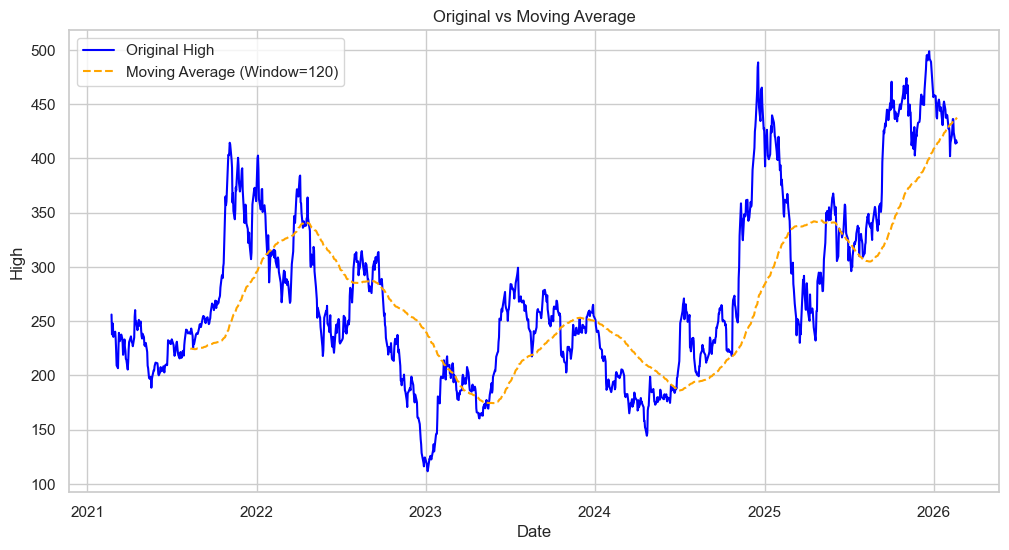

In [21]:
window_size = 120
df['high_smoothed'] = df['high'].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))

plt.plot(df['high'], label='Original High', color='blue')
plt.plot(df['high_smoothed'], label=f'Moving Average (Window={window_size})', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Original vs Moving Average')
plt.legend()
plt.show()

This calculates the moving average of the High column with a window size of 120(A quarter), creating a smoother curve in the high_smoothed series. The plot compares the original High values with the smoothed version.\
<br>
Step 10: Original Data Vs Differenced Data

In [25]:
df_combined = pd.concat([df['high'], df['high_diff']], axis=1)

print(df_combined.head())

                             high  high_diff
date                                        
2021-02-22 00:00:00-05:00  256.17        NaN
2021-02-23 00:00:00-05:00  237.87     -18.30
2021-02-24 00:00:00-05:00  248.33      10.46
2021-02-25 00:00:00-05:00  245.74      -2.59
2021-02-26 00:00:00-05:00  235.57     -10.17


In [26]:
df.dropna(subset=['high_diff'], inplace=True)
df['high_diff'].head()

date
2021-02-23 00:00:00-05:00   -18.30
2021-02-24 00:00:00-05:00    10.46
2021-02-25 00:00:00-05:00    -2.59
2021-02-26 00:00:00-05:00   -10.17
2021-03-01 00:00:00-05:00     4.10
Name: high_diff, dtype: float64

In [27]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['high_diff'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -9.632099014535125
p-value: 1.6020529206187033e-16
Critical Values: {'1%': -3.435630320520318, '5%': -2.863871779019612, '10%': -2.56801146937726}


In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
close,1255.0,2.697083e+02,8.153855e+01,1.081000e+02,2.106950e+02,2.494400e+02,3.220950e+02,4.898800e+02
open,1255.0,2.698543e+02,8.175303e+01,1.030000e+02,2.105950e+02,2.490700e+02,3.220350e+02,4.898800e+02
high,1255.0,2.757022e+02,8.320255e+01,1.117500e+02,2.162000e+02,2.541300e+02,3.302350e+02,4.988300e+02
low,1255.0,2.635901e+02,7.992342e+01,1.018100e+02,2.065050e+02,2.430000e+02,3.150950e+02,4.853300e+02
volume,1255.0,9.891244e+07,3.917038e+07,2.449080e+07,7.027416e+07,9.215070e+07,1.184169e+08,3.065906e+08
high_smoothed,1137.0,2.694548e+02,6.234600e+01,1.745164e+02,2.189775e+02,2.534224e+02,3.202297e+02,4.376501e+02
high_diff,1255.0,1.262947e-01,9.092804e+00,-3.520000e+01,-4.635000e+00,-2.900000e-01,4.710000e+00,4.501000e+01


In [35]:
df.columns.tolist()

['close', 'open', 'high', 'low', 'volume', 'high_smoothed', 'high_diff']